In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
membership = pd.read_excel("../데이터 수정, 추가/membership_v1.xlsx")
viewhistory = pd.read_excel("../Dataset/View_History.xlsx")
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

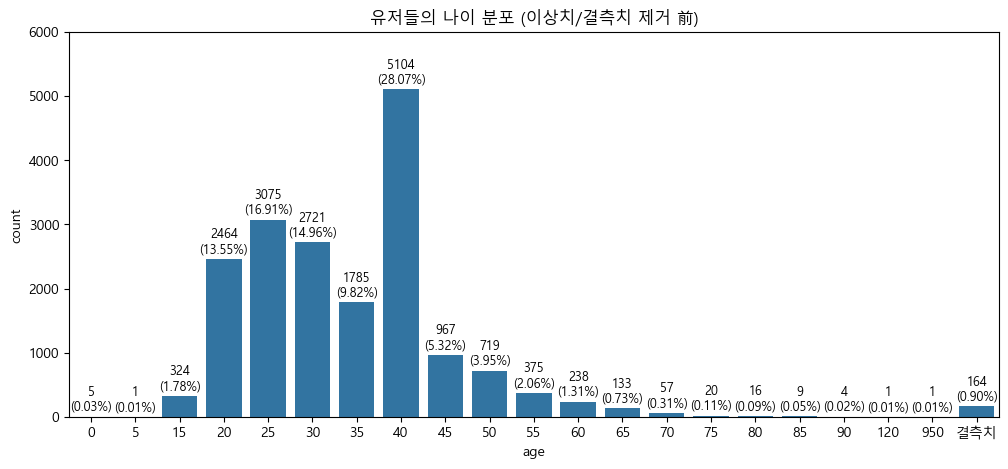

In [3]:
age_plot = membership["age"].apply(
    lambda x: "결측치" if pd.isna(x) else f"{x:g}"
)

age_order = [f"{x:g}" for x in sorted(membership["age"].dropna().unique())] + ["결측치"]

plt.figure(figsize=(12, 5))

ax = sns.countplot(
    x=age_plot,
    order=age_order
)

ax.set_title("유저들의 나이 분포 (이상치/결측치 제거 前)")
ax.set_xlabel("age")
ax.set_ylabel("count")
ax.set_ylim(0, 6000)

total_N = len(age_plot)

for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 50,
        f"{int(height)}\n({height / total_N:.2%})",
        ha="center",
        va="bottom",
        fontsize=9
    )


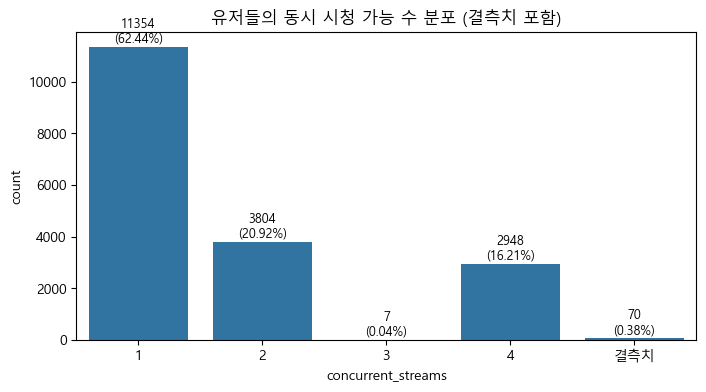

In [15]:
concurrent_plot = membership["concurrent_streams"].apply(
    lambda x: "결측치" if pd.isna(x) else f"{x:g}"
)

concurrent_order = [
    f"{x:g}" for x in sorted(membership["concurrent_streams"].dropna().unique())
] + ["결측치"]

plt.figure(figsize=(8, 4))

ax = sns.countplot(
    x=concurrent_plot,
    order=concurrent_order
)

ax.set_title("유저들의 동시 시청 가능 수 분포 (결측치 포함)")
ax.set_xlabel("concurrent_streams")
ax.set_ylabel("count")

total_N = len(concurrent_plot)

for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + max(total_N * 0.003, 5),
        f"{int(height)}\n({height / total_N:.2%})",
        ha="center",
        va="bottom",
        fontsize=9
    )


> 의심가는 데이터: 0세, 5세, 85세, 90세, 120세, 950세  

자세히 파봐야겠다.

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'android'),
  Text(1, 0, 'pc'),
  Text(2, 0, 'ios'),
  Text(3, 0, 'mobile'),
  Text(4, 0, 'lgtv'),
  Text(5, 0, 'sstv'),
  Text(6, 0, 'ott'),
  Text(7, 0, 'smarttv'),
  Text(8, 0, 'lgchplus'),
  Text(9, 0, 'ott_cjhello')])

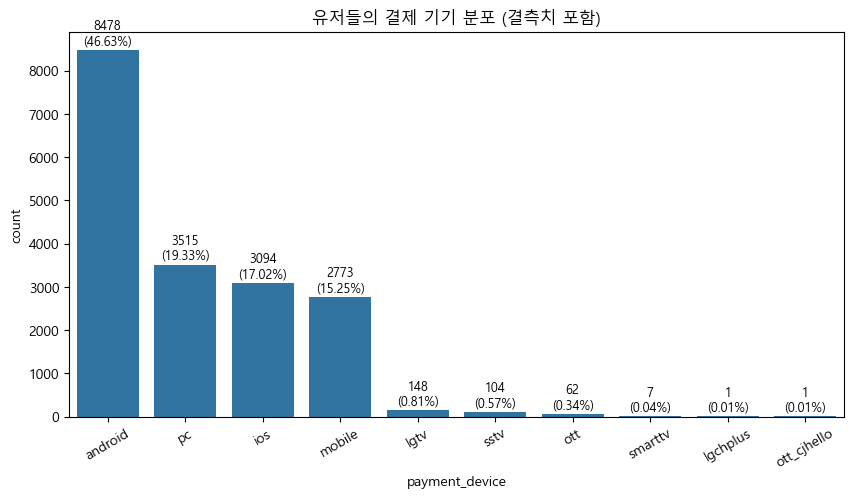

In [16]:
payment_device_plot = membership["payment_device"].fillna("결측치")

payment_device_order = payment_device_plot.value_counts().index.tolist()

plt.figure(figsize=(10, 5))

ax = sns.countplot(
    x=payment_device_plot,
    order=payment_device_order
)

ax.set_title("유저들의 결제 기기 분포 (결측치 포함)")
ax.set_xlabel("payment_device")
ax.set_ylabel("count")

total_N = len(payment_device_plot)

for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + max(total_N * 0.003, 5),
        f"{int(height)}\n({height / total_N:.2%})",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.xticks(rotation=30)


In [5]:
weirdo = membership[
	(membership["age"] == 0) |
	(membership["age"] == 5) |
	(membership["age"] == 85) |
	(membership["age"] == 90) |
	(membership["age"] == 120) |
	(membership["age"] == 950)
]

viewhistory_weirdo = viewhistory[
	viewhistory["USER_ID"].isin(weirdo["USER_ID"])
]

In [6]:
# 시청기록 있는 weirdo
weirdo_watched = weirdo[weirdo["USER_ID"].isin(viewhistory_weirdo["USER_ID"])]

# 시청기록 없는 weirdo
weirdo_not_watched = weirdo[~weirdo["USER_ID"].isin(viewhistory_weirdo["USER_ID"])]

In [7]:
display(weirdo_watched)

,USER_ID,product_cd,amount,billing_method,concurrent_streams,promotion_yn,is_churn_prevented,repurchase,payment_device,is_user_verified,gender,age,reg_date,reg_hour,end_date
2267,16998,pk_1488,100.00,134,2.0,O,NaN,O,android,Y,M,85.0,2021-03-02,16,2021-04-02
3980,19488,pk_2025,100.00,151,1.0,O,O,NaN,android,Y,M,90.0,2021-03-13,21,2021-04-13
4950,4894,pk_1488,10900.00,131,2.0,NaN,NaN,NaN,lgtv,NaN,N,0.0,2021-03-06,22,2021-04-06
5529,18640,pk_2025,7900.00,151,1.0,NaN,NaN,O,android,N,N,950.0,2021-03-02,21,2021-04-02
5629,11912,pk_1489,100.00,134,4.0,O,NaN,NaN,pc,Y,F,90.0,2021-03-07,4,2021-04-07
8311,15446,pk_1487,7900.00,134,1.0,NaN,O,O,android,Y,F,85.0,2021-03-14,6,2021-04-14
8756,1628,pk_1506,13.49,140,2.0,NaN,NaN,NaN,ios,Y,F,85.0,2021-03-11,1,2021-04-12
8858,15096,pk_1487,100.00,134,1.0,O,NaN,O,pc,Y,M,85.0,2021-03-13,10,2021-04-13
9229,19591,pk_1488,10900.00,131,2.0,NaN,NaN,O,mobile,Y,F,85.0,2021-03-10,7,2021-04-10
10345,9491,pk_1489,13900.00,180,4.0,NaN,NaN,NaN,android,N,N,120.0,2021-03-04,0,2021-04-04


In [8]:
display(weirdo_not_watched)

,USER_ID,product_cd,amount,billing_method,concurrent_streams,promotion_yn,is_churn_prevented,repurchase,payment_device,is_user_verified,gender,age,reg_date,reg_hour,end_date
5547,12283,pk_1488,10900.0,134,2.0,NaN,NaN,O,lgtv,NaN,N,0.0,2021-03-07,13,2021-04-07
7406,12815,pk_2025,7900.0,151,1.0,NaN,O,O,android,Y,M,85.0,2021-03-01,3,2021-03-01
7943,11323,pk_1488,10900.0,180,2.0,NaN,NaN,NaN,lgtv,NaN,N,0.0,2021-03-12,22,2021-03-12
9372,10080,pk_1488,10900.0,131,2.0,NaN,NaN,O,lgchplus,NaN,N,0.0,2021-03-02,0,2021-04-02
16830,13963,pk_2026,100.0,151,2.0,O,O,O,android,Y,M,85.0,2021-03-06,12,2021-04-06
17534,693,pk_1489,100.0,132,4.0,O,NaN,NaN,pc,Y,F,85.0,2021-03-09,13,2021-04-09


C:\Users\Administrator\AppData\Local\Temp\ipykernel_11884\3071174431.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\Administrator\AppData\Local\Temp\ipykernel_11884\3071174431.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\Administrator\AppData\Local\Temp\ipykernel_11884\3071174431.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


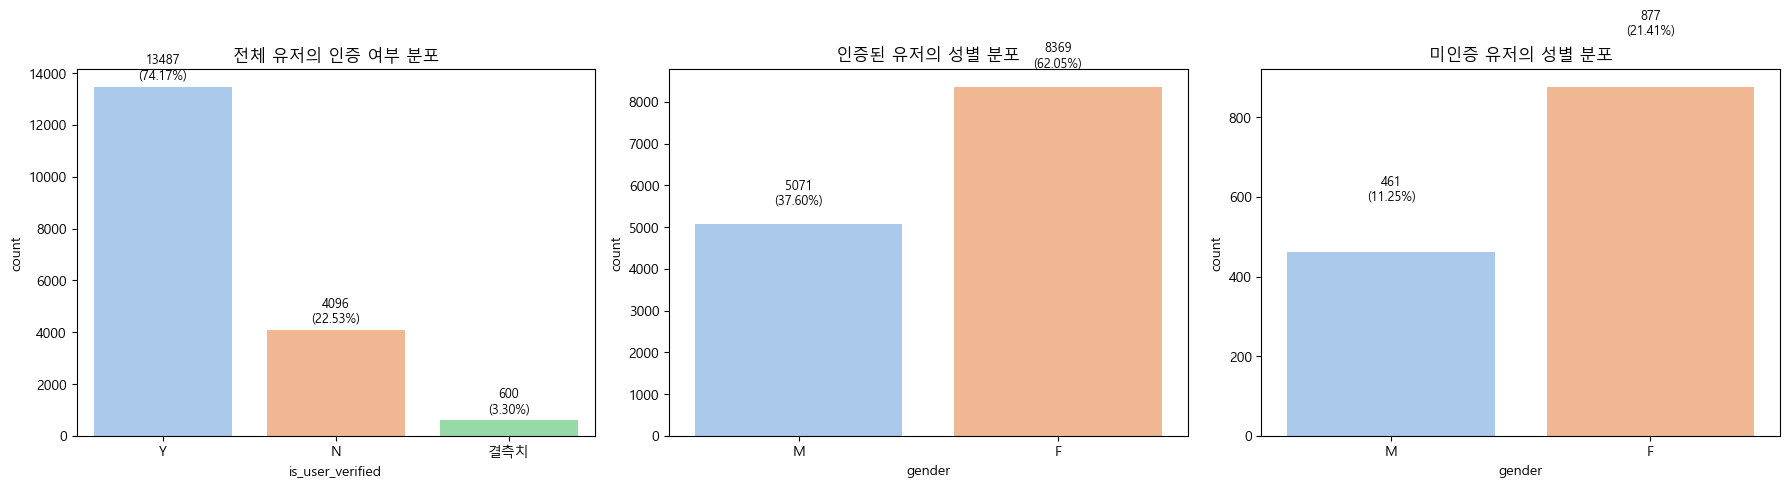

In [36]:
verify_plot = membership["is_user_verified"].fillna("결측치")
verified_gender_plot = membership.loc[
    membership["is_user_verified"] == "Y",
    "gender"
].fillna("결측치")
non_verified_gender_plot = membership.loc[
    membership["is_user_verified"] == "N",
    "gender"
].fillna("결측치")

verify_order = [
    value for value in ["Y", "N", "결측치"]
    if value in verify_plot.value_counts().index
]
gender_order = [
    value for value in ["M", "F", "결측치"]
    if value in pd.concat([verified_gender_plot, non_verified_gender_plot]).value_counts().index
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(
    x=verify_plot,
    order=verify_order,
    palette="pastel",
    ax=axes[0]
)
sns.countplot(
    x=verified_gender_plot,
    order=gender_order,
    palette="pastel",
    ax=axes[1]
)
sns.countplot(
    x=non_verified_gender_plot,
    order=gender_order,
    palette="pastel",
    ax=axes[2]
)

axes[0].set_title("전체 유저의 인증 여부 분포")
axes[0].set_xlabel("is_user_verified")
axes[0].set_ylabel("count")

axes[1].set_title("인증된 유저의 성별 분포")
axes[1].set_xlabel("gender")
axes[1].set_ylabel("count")

axes[2].set_title("미인증 유저의 성별 분포")
axes[2].set_xlabel("gender")
axes[2].set_ylabel("count")

plot_info = [
    (axes[0], len(verify_plot), 0.01),
    (axes[1], len(verified_gender_plot), 0.03),
    (axes[2], len(non_verified_gender_plot), 0.03)
]

for ax, total_N, offset_ratio in plot_info:
    for bar in ax.patches:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + max(total_N * offset_ratio, 5),
            f"{int(height)}\n({height / total_N:.2%})",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()


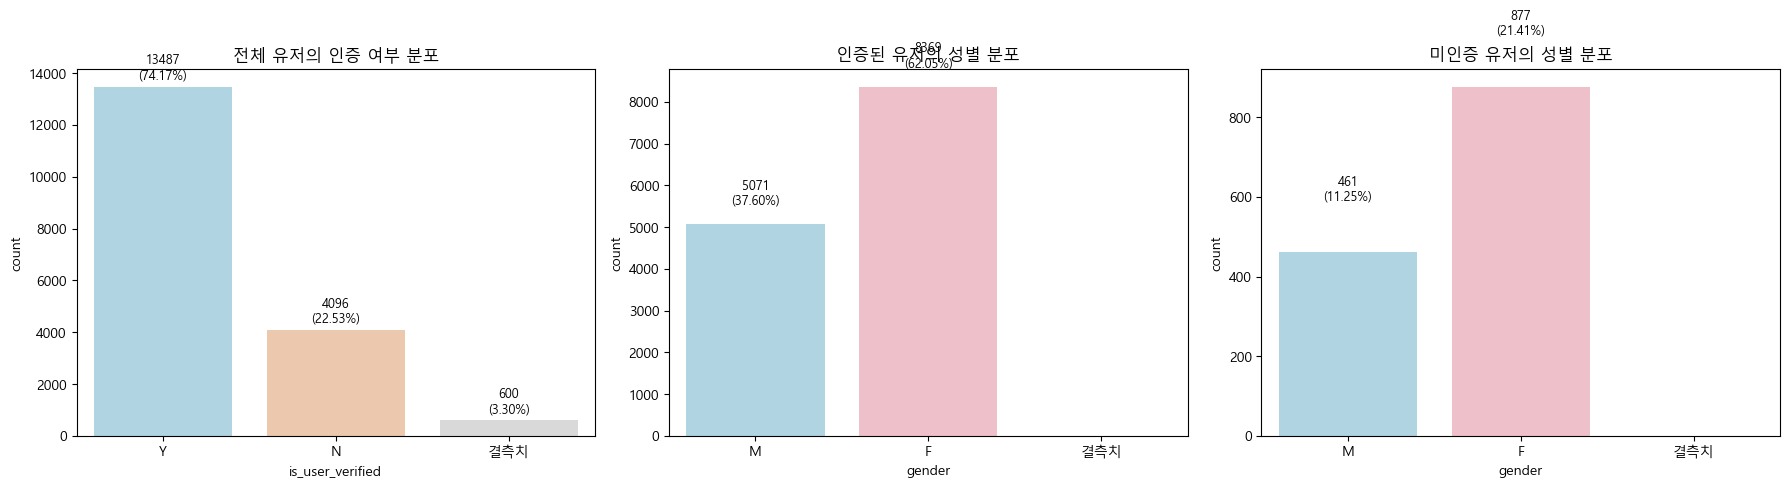

In [37]:
verify_plot = membership["is_user_verified"].fillna("결측치")
verified_gender_plot = membership.loc[
    membership["is_user_verified"] == "Y",
    "gender"
].fillna("결측치")
non_verified_gender_plot = membership.loc[
    membership["is_user_verified"] == "N",
    "gender"
].fillna("결측치")

verify_order = ["Y", "N", "결측치"]
gender_order = ["M", "F", "결측치"]

verify_palette = {
    "Y": "#A8D8EA",
    "N": "#F7C8A3",
    "결측치": "#D9D9D9"
}
gender_palette = {
    "M": "#A8D8EA",
    "F": "#F6B8C4",
    "결측치": "#D9D9D9"
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(
    x=verify_plot,
    order=verify_order,
    hue=verify_plot,
    hue_order=verify_order,
    palette=verify_palette,
    legend=False,
    ax=axes[0]
)
sns.countplot(
    x=verified_gender_plot,
    order=gender_order,
    hue=verified_gender_plot,
    hue_order=gender_order,
    palette=gender_palette,
    legend=False,
    ax=axes[1]
)
sns.countplot(
    x=non_verified_gender_plot,
    order=gender_order,
    hue=non_verified_gender_plot,
    hue_order=gender_order,
    palette=gender_palette,
    legend=False,
    ax=axes[2]
)

axes[0].set_title("전체 유저의 인증 여부 분포")
axes[0].set_xlabel("is_user_verified")
axes[0].set_ylabel("count")

axes[1].set_title("인증된 유저의 성별 분포")
axes[1].set_xlabel("gender")
axes[1].set_ylabel("count")

axes[2].set_title("미인증 유저의 성별 분포")
axes[2].set_xlabel("gender")
axes[2].set_ylabel("count")

plot_info = [
    (axes[0], len(verify_plot), 0.01),
    (axes[1], len(verified_gender_plot), 0.03),
    (axes[2], len(non_verified_gender_plot), 0.03)
]

for ax, total_N, offset_ratio in plot_info:
    for bar in ax.patches:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + max(total_N * offset_ratio, 5),
            f"{int(height)}\n({height / total_N:.2%})",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()


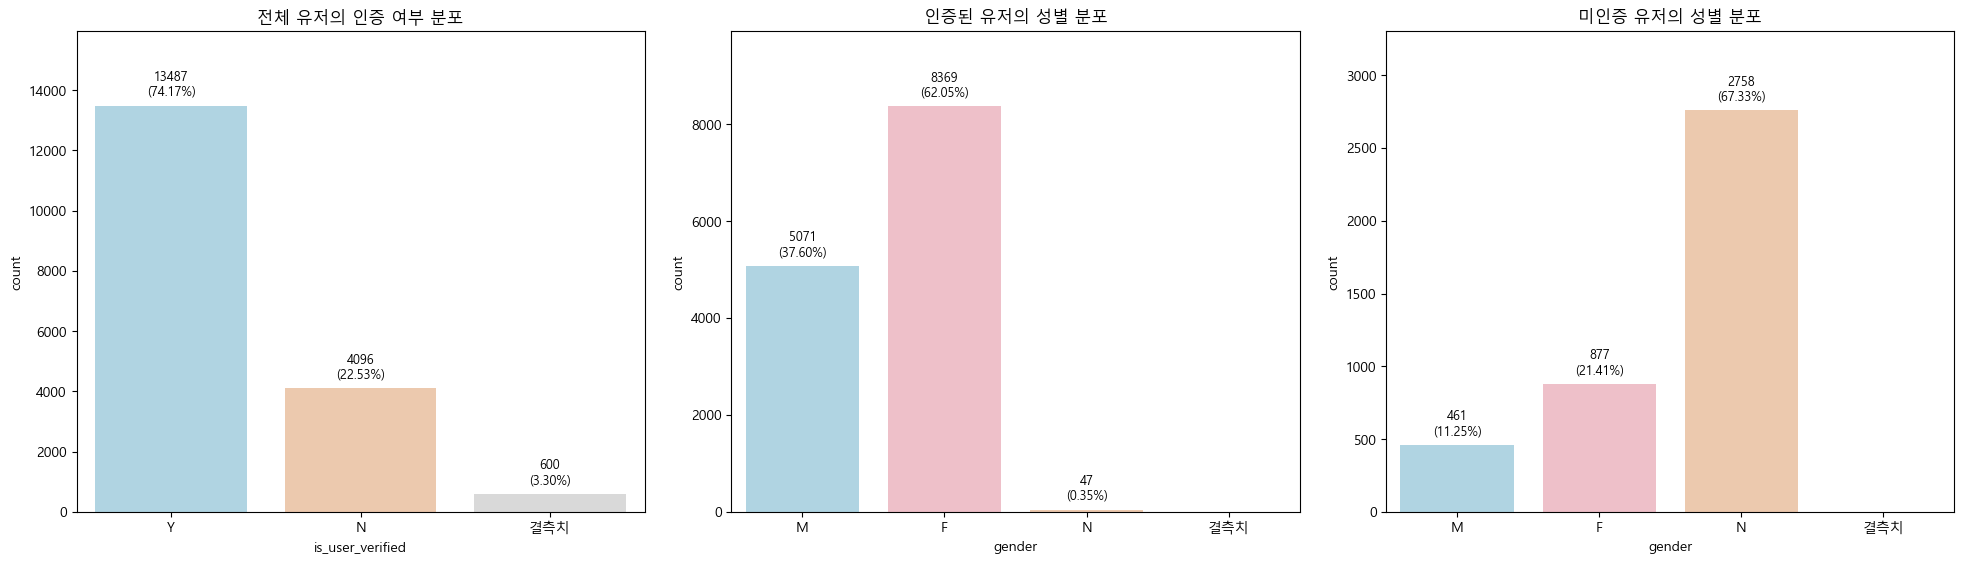

In [38]:
verify_plot = membership["is_user_verified"].fillna("결측치")
verified_gender_plot = membership.loc[
    membership["is_user_verified"] == "Y",
    "gender"
].fillna("결측치")
non_verified_gender_plot = membership.loc[
    membership["is_user_verified"] == "N",
    "gender"
].fillna("결측치")

verify_order = ["Y", "N", "결측치"]
gender_order = ["M", "F", "N", "결측치"]

verify_palette = {
    "Y": "#A8D8EA",
    "N": "#F7C8A3",
    "결측치": "#D9D9D9"
}
gender_palette = {
    "M": "#A8D8EA",
    "F": "#F6B8C4",
    "N": "#F7C8A3",
    "결측치": "#D9D9D9"
}

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.countplot(
    x=verify_plot,
    order=verify_order,
    hue=verify_plot,
    hue_order=verify_order,
    palette=verify_palette,
    legend=False,
    ax=axes[0]
)
sns.countplot(
    x=verified_gender_plot,
    order=gender_order,
    hue=verified_gender_plot,
    hue_order=gender_order,
    palette=gender_palette,
    legend=False,
    ax=axes[1]
)
sns.countplot(
    x=non_verified_gender_plot,
    order=gender_order,
    hue=non_verified_gender_plot,
    hue_order=gender_order,
    palette=gender_palette,
    legend=False,
    ax=axes[2]
)

axes[0].set_title("전체 유저의 인증 여부 분포")
axes[0].set_xlabel("is_user_verified")
axes[0].set_ylabel("count")

axes[1].set_title("인증된 유저의 성별 분포")
axes[1].set_xlabel("gender")
axes[1].set_ylabel("count")

axes[2].set_title("미인증 유저의 성별 분포")
axes[2].set_xlabel("gender")
axes[2].set_ylabel("count")

plot_info = [
    (axes[0], len(verify_plot)),
    (axes[1], len(verified_gender_plot)),
    (axes[2], len(non_verified_gender_plot))
]

for ax, total_N in plot_info:
    max_height = max(bar.get_height() for bar in ax.patches)
    upper_limit = max_height * 1.18 + 50
    ax.set_ylim(0, upper_limit)

    for bar in ax.patches:
        height = bar.get_height()
        y_pos = height + upper_limit * 0.015
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            y_pos,
            f"{int(height)}\n({height / total_N:.2%})",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout(pad=2.0)
